In [1]:
import sys, json
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

INPUT = Path("/kaggle/input")
print("Attached datasets:", [d.name for d in sorted(INPUT.iterdir())])

hits = list(INPUT.glob("**/train_images.npy"))
assert hits, "train_images.npy not found - is the tensors dataset attached?"
TENSORS = hits[0].parent

src_hits = list(INPUT.glob("**/src/localise.py"))
assert src_hits, ("src/localise.py not found - attach the src dataset. The "
                  "folder must be named 'src' for the relative imports to work.")
SRC_PARENT = src_hits[0].parent.parent
sys.path.insert(0, str(SRC_PARENT))

from src import config
from src.localise import (build_unet, bce_dice_loss, dice_coefficient,
                          hard_iou, _augment_pair, mask_to_box, box_iou)

# Run-2 guard. Kaggle pins a dataset VERSION, so a Save & Run All against the
# previous ddsm-src looks entirely normal until you read the manifest three
# hours later. This must come AFTER the import: config does not exist before it.
assert config.LOC_BASE_FILTERS == 48, f"stale src: filters={config.LOC_BASE_FILTERS}"
assert config.LOC_BATCH_SIZE == 4, f"stale src: batch={config.LOC_BATCH_SIZE}"
assert config.LOC_RLROP_PATIENCE == 8, f"stale src: rlrop={config.LOC_RLROP_PATIENCE}"
print(f"[run2] filters={config.LOC_BASE_FILTERS} depth={config.LOC_DEPTH} "
      f"batch={config.LOC_BATCH_SIZE} lr={config.LOC_LR} "
      f"epochs={config.LOC_EPOCHS} rlrop={config.LOC_RLROP_PATIENCE} "
      f"es_patience={config.LOC_PATIENCE}")

RUN = "run2_base48"
OUT = Path("/kaggle/working") / RUN
OUT.mkdir(parents=True, exist_ok=True)
config.set_seeds(config.SEED)

gpu = tf.config.list_physical_devices("GPU")
assert gpu, "No GPU - set Accelerator to GPU T4 x2 in Session options"

print(f"TENSORS  = {TENSORS}")
print(f"SRC path = {SRC_PARENT}")
print(f"GPU      = {gpu}")
print(f"canvas {config.LOC_INPUT_H}x{config.LOC_INPUT_W} | seed {config.SEED}")
print(f"OUT      = {OUT}")

Attached datasets: ['datasets']
[run2] filters=48 depth=4 batch=4 lr=0.001 epochs=120 rlrop=8 es_patience=20
TENSORS  = /kaggle/input/datasets/tataruteodor/localiser-tensors
SRC path = /kaggle/input/datasets/tataruteodor/ddsm-src
GPU      = [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]
canvas 1024x576 | seed 28
OUT      = /kaggle/working/run2_base48


I0000 00:00:1788778918.853674      23 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1788778918.856526      23 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


In [2]:
BATCH = config.LOC_BATCH_SIZE

def make_ds(split, batch=BATCH, shuffle=False, augment=False):
    """Datasets straight from the precomputed letterboxed tensors.

    No DICOM decode and no tf.data cache - the arrays are already the exact
    model inputs, verified against re-decoded DICOMs to within 2.4e-4.
    """
    imgs = np.load(TENSORS / f"{split}_images.npy")
    msks = np.load(TENSORS / f"{split}_masks.npy")
    scale = 255.0 if imgs.dtype == np.uint8 else 1.0
    print(f"{split}: {len(imgs)} pairs | {imgs.dtype} | {imgs.nbytes/1e6:.0f} MB "
          f"| mean fg {msks.mean():.5f}")
    ds = tf.data.Dataset.from_tensor_slices((imgs, msks)).map(
        lambda i, m: (tf.cast(i, tf.float32)[..., None] / scale,
                      tf.cast(m, tf.float32)[..., None]),
        num_parallel_calls=tf.data.AUTOTUNE)
    if shuffle:
        ds = ds.shuffle(len(imgs), seed=config.SEED, reshuffle_each_iteration=True)
    ds = ds.batch(batch)
    if augment:
        ds = ds.map(_augment_pair, num_parallel_calls=tf.data.AUTOTUNE)
    return ds.prefetch(tf.data.AUTOTUNE)

train_ds = make_ds("train", shuffle=True, augment=True)
val_ds   = make_ds("val")
test_ds  = make_ds("test")

i0, m0 = next(iter(train_ds))
print(f"\nbatch {i0.shape} range [{tf.reduce_min(i0):.3f}, {tf.reduce_max(i0):.3f}]"
      f" | fg {m0.numpy().mean():.5f}")
assert tf.reduce_max(i0) > 0.5, "images look wrong - check the dtype/scale"
assert 0.0001 < m0.numpy().mean() < 0.2, "masks look wrong - check the upload"

train: 1210 pairs | float16 | 1427 MB | mean fg 0.00471
val: 243 pairs | float16 | 287 MB | mean fg 0.00412
test: 243 pairs | float16 | 287 MB | mean fg 0.00443

batch (4, 1024, 576, 1) range [0.000, 1.000] | fg 0.00696


In [3]:
# Halves activation memory and uses T4 tensor cores. Must be set BEFORE
# build_unet - layer dtypes are fixed at construction. The output layer is
# already forced to float32 in build_unet, so the loss stays in full precision;
# at 0.34% foreground an fp16 sigmoid would underflow and Dice would collapse.
tf.keras.mixed_precision.set_global_policy("mixed_float16")
print("policy:", tf.keras.mixed_precision.global_policy().name)

model = build_unet()

opt = tf.keras.optimizers.Adam(config.LOC_LR)
LSO = (getattr(tf.keras.optimizers, "LossScaleOptimizer", None)
       or getattr(tf.keras.mixed_precision, "LossScaleOptimizer", None))
if LSO is not None and not isinstance(opt, LSO):
    opt = LSO(opt)

model.compile(optimizer=opt, loss=bce_dice_loss,
              metrics=[dice_coefficient, hard_iou])

bias = float(model.get_layer("lesion_prob").get_weights()[1][0])
print(f"{model.count_params():,} params")
print(f"output dtype = {model.output.dtype}   (must be float32)")
print(f"output bias  = {bias:.3f}   (prior init should be about -5.68)")
assert bias < -4.0, "output bias not prior-initialised - update build_unet"
assert model.output.dtype == tf.float32, "output must stay float32 under fp16"

policy: mixed_float16
17,469,361 params
output dtype = float32   (must be float32)
output bias  = -5.681   (prior init should be about -5.68)


In [4]:
EPOCHS = config.LOC_EPOCHS

cbs = [
    # Selection and stopping both move from val_hard_iou to val_loss.
    # In run 1, val_hard_iou swung by up to 0.17 between adjacent epochs
    # (0.216 -> 0.044 -> 0.216 across epochs 9-13) while training climbed
    # smoothly, because the training metric is an average over 303 steps while
    # the validation metric is a snapshot of a noisy walk. Taking the maximum
    # over ~90 such draws biases the reported best upward, and makes WHICH
    # weights we keep partly luck: epochs 60, 63, 67 and 68 were all within
    # 0.002 of each other. val_loss is smooth, is what the model actually
    # optimises, and on run 1 it selects epoch 49 - whose val_hard_iou (0.3634)
    # is within 0.002 of the noisy criterion's pick (0.3649). Same model, chosen
    # by a criterion that is not a lottery.
    #
    # It also makes the three callbacks agree: previously EarlyStopping restored
    # the val_hard_iou best while ModelCheckpoint wrote the val_hard_iou best and
    # ReduceLROnPlateau tracked val_loss. Now the restored model and the file on
    # disk are the same model by construction.
    tf.keras.callbacks.EarlyStopping(
        monitor="val_loss", mode="min",
        patience=config.LOC_PATIENCE,
        start_from_epoch=config.LOC_START_FROM_EPOCH,
        restore_best_weights=True, verbose=1),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss", mode="min", factor=0.5,
        patience=config.LOC_RLROP_PATIENCE, min_lr=1e-6, verbose=1),
    # Weights only. A .keras file is a zip archive, and Kaggle's download
    # unpacks it into config.json / metadata.json / model.weights.h5; worse, the
    # archived config records the T4's per-layer mixed_float16 policies, which
    # load_model would faithfully rebuild on a machine with no float16 compute.
    # The architecture is fully determined by config (recorded in the manifest),
    # so the weights are the only thing that needs saving.
    tf.keras.callbacks.ModelCheckpoint(
        str(OUT / "best.weights.h5"), monitor="val_loss", mode="min",
        save_best_only=True, save_weights_only=True, verbose=1),
    tf.keras.callbacks.CSVLogger(str(OUT / "history.csv")),
]

history = model.fit(train_ds, validation_data=val_ds,
                    epochs=EPOCHS, callbacks=cbs, verbose=1)

Epoch 1/120


2026-09-07 11:03:15.757209: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-09-07 11:03:15.978969: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-09-07 11:03:17.878952: E external/local_xla/xla/service/slow_operation_alarm.cc:73] Trying algorithm eng0{} for conv (f16[4,1024,576,48]{3,2,1,0}, u8[0]{0}) custom-call(f16[4,1024,576,48]{3,2,1,0}, f16[48,3,3,48]{3,2,1,0}), window={size=3x3 pad=1_1x1_1}, dim_labels=b01f_o01i->b01f, custom_call_target="__cudnn$convBackwardInput", backend_config={"operation_queue_id":"0","wait_on_operation_queues":[],"cudnn_conv_backend_config":{"activation_mode":"kNone","conv_result_scale":1,"side_input_scale":0,"leakyrelu_alpha":0},"for

302/303 ━━━━━━━━━━━━━━━━━━━━ 0s 490ms/step - dice_coefficient: 0.0772 - hard_iou: 0.0550 - loss: 0.4790

2026-09-07 11:08:26.343981: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-09-07 11:08:26.564191: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-09-07 11:08:28.076080: E external/local_xla/xla/service/slow_operation_alarm.cc:73] Trying algorithm eng0{} for conv (f16[2,1024,576,48]{3,2,1,0}, u8[0]{0}) custom-call(f16[2,1024,576,48]{3,2,1,0}, f16[48,3,3,48]{3,2,1,0}), window={size=3x3 pad=1_1x1_1}, dim_labels=b01f_o01i->b01f, custom_call_target="__cudnn$convBackwardInput", backend_config={"operation_queue_id":"0","wait_on_operation_queues":[],"cudnn_conv_backend_config":{"activation_mode":"kNone","conv_result_scale":1,"side_input_scale":0,"leakyrelu_alpha":0},"for

303/303 ━━━━━━━━━━━━━━━━━━━━ 0s 783ms/step - dice_coefficient: 0.0773 - hard_iou: 0.0551 - loss: 0.4790
Epoch 1: val_loss improved from None to 0.54579, saving model to /kaggle/working/run2_base48/best.weights.h5

Epoch 1: finished saving model to /kaggle/working/run2_base48/best.weights.h5
303/303 ━━━━━━━━━━━━━━━━━━━━ 463s 907ms/step - dice_coefficient: 0.0945 - hard_iou: 0.0673 - loss: 0.4710 - val_dice_coefficient: 0.0010 - val_hard_iou: 0.0000e+00 - val_loss: 0.5458 - learning_rate: 0.0010
Epoch 2/120
303/303 ━━━━━━━━━━━━━━━━━━━━ 0s 486ms/step - dice_coefficient: 0.1401 - hard_iou: 0.0948 - loss: 0.4489
Epoch 2: val_loss improved from 0.54579 to 0.46928, saving model to /kaggle/working/run2_base48/best.weights.h5

Epoch 2: finished saving model to /kaggle/working/run2_base48/best.weights.h5
303/303 ━━━━━━━━━━━━━━━━━━━━ 159s 520ms/step - dice_coefficient: 0.1496 - hard_iou: 0.1006 - loss: 0.4447 - val_dice_coefficient: 0.1177 - val_hard_iou: 0.0833 - val_loss: 0.4693 - learning_rate

{
  "run": "run2_base48",
  "device": "{'compute_capability': (7, 5), 'device_name': 'Tesla T4'}",
  "lr": 0.001,
  "batch_size": 4,
  "epochs_requested": 120,
  "epochs_run": 48,
  "seed": 28,
  "input": [
    1024,
    576
  ],
  "depth": 4,
  "base_filters": 48,
  "params": 17469361,
  "dice_bce_weights": [
    0.5,
    0.5
  ],
  "output_prior_bias": -5.6805739402771,
  "input_dtype": "float16",
  "precision": "mixed_float16",
  "steps_per_epoch": 303,
  "selection_metric": "val_loss",
  "early_stopping_patience": 20,
  "start_from_epoch": 20,
  "rlrop_patience": 8,
  "best_epoch": 30,
  "val_loss_at_best_epoch": NaN,
  "val_hard_iou_at_best_epoch": 0.0,
  "val_dice_at_best_epoch": NaN,
  "train_hard_iou_at_best_epoch": 0.3017438054084778,
  "max_val_hard_iou_any_epoch": 0.2840855121612549,
  "max_val_dice_any_epoch": 0.3773224949836731,
  "final_train_loss": NaN,
  "all_background_loss": 0.534
}

train - val hard_iou at the selected epoch: +0.3017
run 1 (base 32) at its val_loss-b

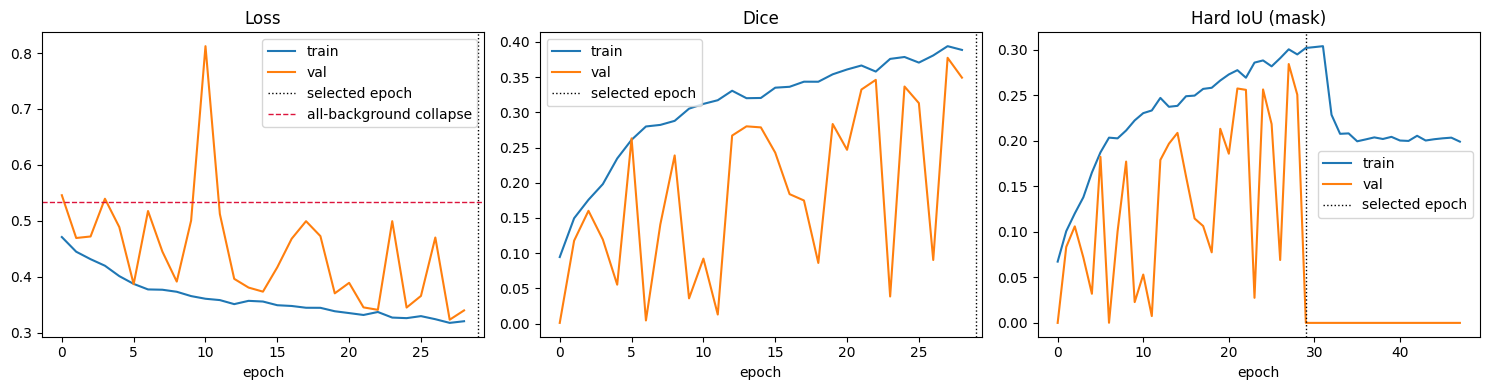

In [5]:
h = history.history
best_i = int(np.argmin(h["val_loss"]))       # the selection metric for run 2
n_train = int(np.load(TENSORS / "train_images.npy", mmap_mode="r").shape[0])

manifest = {
    "run": RUN,
    "device": str(tf.config.experimental.get_device_details(gpu[0])),
    "lr": config.LOC_LR,
    "batch_size": BATCH,
    "epochs_requested": EPOCHS,
    "epochs_run": len(h["loss"]),
    "seed": config.SEED,
    "input": [config.LOC_INPUT_H, config.LOC_INPUT_W],
    "depth": config.LOC_DEPTH,
    "base_filters": config.LOC_BASE_FILTERS,
    "params": int(model.count_params()),
    "dice_bce_weights": list(config.LOC_DICE_BCE_WEIGHTS),
    "output_prior_bias": bias,
    "input_dtype": str(np.load(TENSORS / "train_images.npy", mmap_mode="r").dtype),
    "precision": tf.keras.mixed_precision.global_policy().name,
    "steps_per_epoch": int(np.ceil(n_train / BATCH)),
    "selection_metric": "val_loss",
    "early_stopping_patience": config.LOC_PATIENCE,
    "start_from_epoch": config.LOC_START_FROM_EPOCH,
    "rlrop_patience": config.LOC_RLROP_PATIENCE,
    # The restored model comes from best_epoch. These are the numbers to quote.
    "best_epoch": best_i + 1,
    "val_loss_at_best_epoch": float(h["val_loss"][best_i]),
    "val_hard_iou_at_best_epoch": float(h["val_hard_iou"][best_i]),
    "val_dice_at_best_epoch": float(h["val_dice_coefficient"][best_i]),
    "train_hard_iou_at_best_epoch": float(h["hard_iou"][best_i]),
    # Maxima over the whole run. NOT the restored model, and biased upward as
    # estimates because each is a maximum over ~90 correlated noisy evaluations.
    # Run 1's headline 0.3649 was one of these; its restored model is what
    # matters. Kept only so the two runs stay comparable on the old basis.
    "max_val_hard_iou_any_epoch": float(max(h["val_hard_iou"])),
    "max_val_dice_any_epoch": float(max(h["val_dice_coefficient"])),
    "final_train_loss": float(h["loss"][-1]),
    "all_background_loss": 0.534,
}
(OUT / "manifest.json").write_text(json.dumps(manifest, indent=2))
print(json.dumps(manifest, indent=2))

gap = (manifest["train_hard_iou_at_best_epoch"]
       - manifest["val_hard_iou_at_best_epoch"])
print(f"\ntrain - val hard_iou at the selected epoch: {gap:+.4f}")
print(f"run 1 (base 32) at its val_loss-best epoch 49: +0.0042  "
      f"[train 0.36764, val 0.36340, val_loss 0.28017]")
print("A gap that is still near zero means 2.25x the parameters bought nothing "
      "and the ceiling is the task, not the model.")

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, key, title in zip(axes, ["loss", "dice_coefficient", "hard_iou"],
                          ["Loss", "Dice", "Hard IoU (mask)"]):
    ax.plot(h[key], label="train")
    ax.plot(h[f"val_{key}"], label="val")
    ax.axvline(best_i, ls=":", c="k", lw=1, label="selected epoch")
    if key == "loss":
        ax.axhline(0.534, ls="--", c="crimson", lw=1,
                   label="all-background collapse")
    ax.set_title(title); ax.set_xlabel("epoch"); ax.legend()
plt.tight_layout()
fig.savefig(OUT / "training_curves.png", dpi=150)
plt.show()

61/61 ━━━━━━━━━━━━━━━━━━━━ 16s 190ms/step

val lesions 243 | with GT box 243 | no GT 0
Detection rate (a box was produced): 91.4%
Box IoU, miss-inclusive   mean 0.341 | median 0.376   <-- GATE METRIC
Box IoU, given detection  mean 0.373 | median 0.482
IoU >= 0.50: 44.0%   IoU >= 0.30: 51.0%

W20 GATE: PASS - keep the supervised localiser
Run 1 printed 0.351 on a 64-lesion subset by an unstated denominator, so it is not comparable with this number.


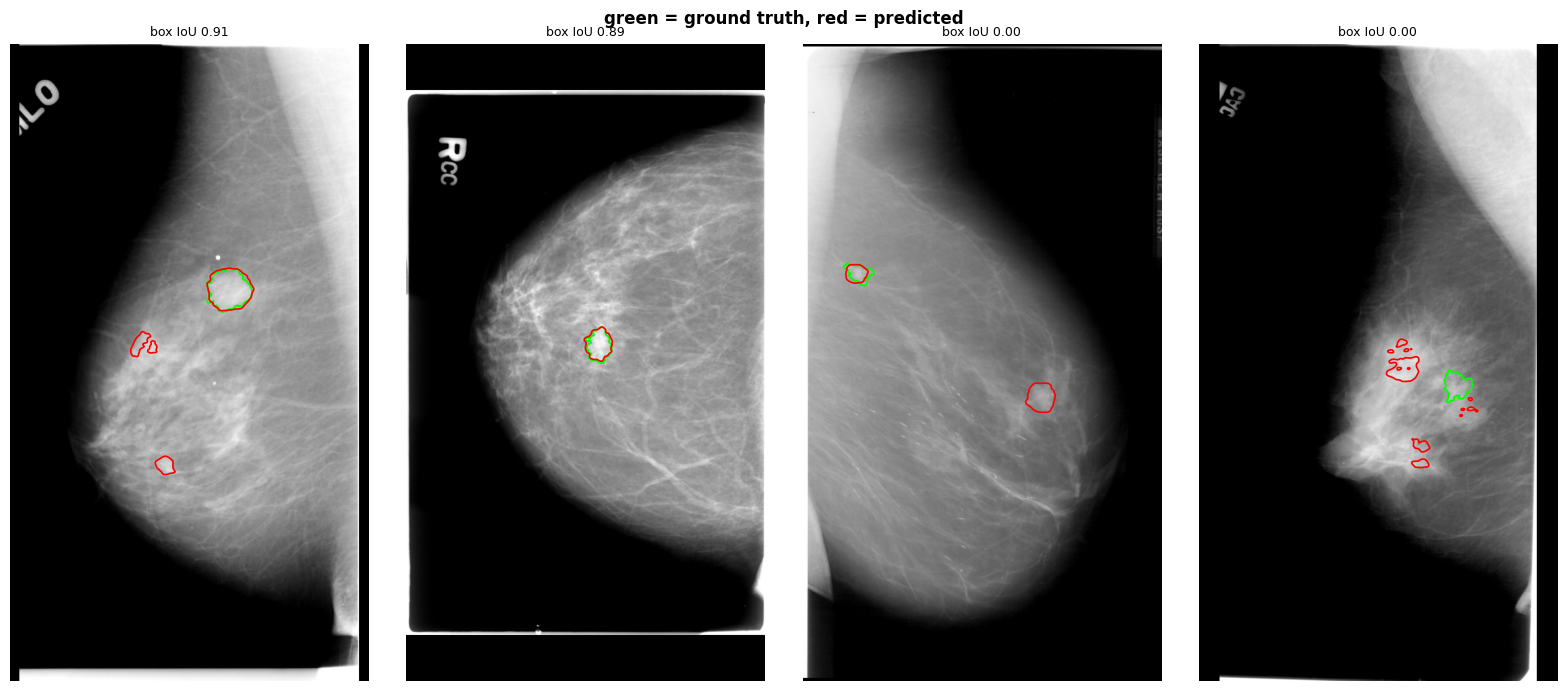

In [6]:
# hard_iou is MASK IoU. The gate is BOX IoU >= 0.30, which is what the crop
# pipeline consumes. They are not the same number, and box IoU is usually the
# higher of the two: a box circumscribing a ragged mask still overlaps well.
#
# This mirrors src/localise_eval.report() so the Kaggle figure and the local
# one are directly comparable. Two denominators, kept apart:
#   scored   = lesions that have a ground-truth box at all
#   detected = of those, the ones the localiser actually fired on
# The gate metric is miss-inclusive - a miss scores 0 - because a localiser
# that finds a tenth of the lesions perfectly is not a usable localiser.
imgs = np.load(TENSORS / "val_images.npy")
msks = np.load(TENSORS / "val_masks.npy")
scale = 255.0 if imgs.dtype == np.uint8 else 1.0

probs = model.predict(imgs.astype(np.float32)[..., None] / scale,
                      batch_size=BATCH, verbose=1)[..., 0]

rows = []
for i in range(len(imgs)):
    # min_px=1, keep_largest=False for GROUND TRUTH. The config defaults
    # (min_px=64, keep_largest=True) exist to clean up noisy PREDICTIONS;
    # applied to ground truth they discard small true lesions and depress
    # every rate below.
    gt = mask_to_box(msks[i].astype(np.float32), threshold=0.5,
                     min_px=1, keep_largest=False)
    pr = mask_to_box(probs[i])           # config thresholds + largest component
    if gt is None:
        iou = np.nan                     # no ground truth: not scoreable
    elif pr is None:
        iou = 0.0                        # localiser miss: scored as zero
    else:
        iou = box_iou(gt, pr)
    rows.append({"i": i, "has_gt": gt is not None,
                 "detected": pr is not None, "box_iou": iou})

r = pd.DataFrame(rows)
scored = r[r["has_gt"]]
det = scored[scored["detected"]]

print(f"\nval lesions {len(r)} | with GT box {len(scored)} | no GT {int((~r['has_gt']).sum())}")
print(f"Detection rate (a box was produced): {scored['detected'].mean():.1%}")
print(f"Box IoU, miss-inclusive   mean {scored['box_iou'].mean():.3f} "
      f"| median {scored['box_iou'].median():.3f}   <-- GATE METRIC")
print(f"Box IoU, given detection  mean {det['box_iou'].mean():.3f} "
      f"| median {det['box_iou'].median():.3f}")
print(f"IoU >= 0.50: {(scored['box_iou'] >= 0.5).mean():.1%}   "
      f"IoU >= 0.30: {(scored['box_iou'] >= 0.3).mean():.1%}")

gate = scored["box_iou"].mean() >= 0.30
print(f"\nW20 GATE: "
      f"{'PASS - keep the supervised localiser' if gate else 'FAIL - fall back to CAM-only'}")
print("Run 1 printed 0.351 on a 64-lesion subset by an unstated denominator, "
      "so it is not comparable with this number.")

best = scored.sort_values("box_iou", ascending=False)
show = list(best["i"][:2]) + list(best["i"][-2:])
fig, axes = plt.subplots(1, 4, figsize=(16, 7))
for ax, i in zip(axes, show):
    ax.imshow(imgs[i].astype(np.float32) / scale, cmap="gray")
    ax.contour(msks[i], levels=[0.5], colors="lime", linewidths=1.2)
    ax.contour(probs[i], levels=[0.5], colors="red", linewidths=1.2)
    ax.set_title(f"box IoU {r.loc[i, 'box_iou']:.2f}", fontsize=9)
    ax.axis("off")
plt.suptitle("green = ground truth, red = predicted", fontweight="bold")
plt.tight_layout()
fig.savefig(OUT / "prediction_examples.png", dpi=150)
plt.show()